In [29]:
from pathlib import Path
import os
import sys

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    current = start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing both 'config.yaml' and 'data' directory."
    )

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("cwd =", Path.cwd())

PROJECT_ROOT = /home/zakhar/PycharmProjects/PythonProject5
cwd = /home/zakhar/PycharmProjects/PythonProject5


In [30]:
import gc
import time
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

from pathlib import Path
from tqdm.auto import tqdm

from src.baselines import (
    imbalance_score,
    fit_score_calibrator,
    apply_score_calibrator,
)
from src.models import fit_lgbm, fit_ridge
from src.metrics import regression_metrics

In [31]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

baseline_metrics = pd.read_csv("outputs/tables/baseline_metrics_light.csv")
baseline_metrics.head()

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,horizon_sec,split
0,197350,0.000069,0.000040,0.012123,0.155258,0.210693,imbalance_calibrated,1,test
1,197350,0.000070,0.000036,-0.009453,0.006447,0.265295,microprice_calibrated,1,test
2,197350,0.000070,0.000036,-0.011501,NaN,NaN,zero,1,test
3,591998,0.000074,0.000044,0.024312,0.155922,0.204755,imbalance_calibrated,1,train
4,591998,0.000075,0.000040,0.000001,0.001051,0.227886,microprice_calibrated,1,train


In [32]:
best_h = 1
reference_baseline = "imbalance_calibrated"

print("Fixed horizon for ablation:", best_h)
print("Reference baseline:", reference_baseline)

Fixed horizon for ablation: 1
Reference baseline: imbalance_calibrated


In [33]:
baseline_metrics.query("horizon_sec == 1 and split in ['val', 'test']").sort_values(
    ["split", "pearson_ic"], ascending=[True, False]
)

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,horizon_sec,split
0,197350,0.000069,0.000040,0.012123,0.155258,0.210693,imbalance_calibrated,1,test
1,197350,0.000070,0.000036,-0.009453,0.006447,0.265295,microprice_calibrated,1,test
2,197350,0.000070,0.000036,-0.011501,NaN,NaN,zero,1,test
7,196165,0.000059,0.000030,-0.003555,0.156487,0.232970,microprice_calibrated,1,val
6,196165,0.000058,0.000034,0.009986,0.132712,0.191608,imbalance_calibrated,1,val
8,196165,0.000059,0.000030,-0.005104,NaN,NaN,zero,1,val


In [34]:
targets_df = pd.read_parquet(cfg["data"]["targets_path"])
print(targets_df.shape)
targets_df.head()

(987938, 22)


,row_id,timestamp,event_dt,file_date,session_type,session_id,split,future_dt_1s,future_mid_1s,valid_target_1s,...,future_dt_5s,future_mid_5s,valid_target_5s,delta_mid_5s,y_logret_5s,future_dt_10s,future_mid_10s,valid_target_10s,delta_mid_10s,y_logret_10s
0,0,1748941200153000000,2025-06-03 09:00:00.153000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.250,10.9415,True,0.0085,0.000777
1,1,1748941200390000000,2025-06-03 09:00:00.390000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.447000000,10.9320,True,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.563,10.9415,True,0.0085,0.000777
2,2,1748941200767000000,2025-06-03 09:00:00.767000000,20250603,main,20250603_main,train,2025-06-03 09:00:01.787000002,10.9320,True,...,2025-06-03 09:00:05.990000002,10.934,True,0.0010,0.000091,2025-06-03 09:00:11.057,10.9415,True,0.0085,0.000777
3,3,1748941201003000002,2025-06-03 09:00:01.003000002,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.030000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823
4,4,1748941201053000000,2025-06-03 09:00:01.053000000,20250603,main,20250603_main,train,2025-06-03 09:00:02.403000000,10.9325,True,...,2025-06-03 09:00:06.057000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823


In [35]:
pf = pq.ParquetFile(cfg["data"]["clean_path"])
all_cols = pf.schema.names

print("n_cols:", len(all_cols))
print(all_cols)

n_cols: 100
['timestamp', 'best_bid_price', 'best_bid_volume', 'best_ask_price', 'best_ask_volume', 'mid_price', 'spread', 'imbalance_l1', 'total_bid_volume', 'weighted_bid_volume', 'total_ask_volume', 'weighted_ask_volume', 'imbalance_depth_weighted', 'microprice', 'num_orders_best_bid', 'num_orders_best_ask', 'order_count_imbalance', 'price_change', 'market_impact_depth', 'market_impact_spread', 'bid_volume_change', 'ask_volume_change', 'microprice_mean_1s', 'microprice_std_1s', 'volatility_mid_1s', 'volatility_best_bid_1s', 'volatility_best_ask_1s', 'imbalance_mean_1s', 'imbalance_std_1s', 'spread_mean_1s', 'spread_std_1s', 'bid_volume_flow_1s', 'ask_volume_flow_1s', 'microprice_mean_3s', 'microprice_std_3s', 'volatility_mid_3s', 'volatility_best_bid_3s', 'volatility_best_ask_3s', 'imbalance_mean_3s', 'imbalance_std_3s', 'spread_mean_3s', 'spread_std_3s', 'bid_volume_flow_3s', 'ask_volume_flow_3s', 'hurst_exponent_3s', 'microprice_mean_5s', 'microprice_std_5s', 'volatility_mid_5s', 

In [36]:
block_l1 = [
    "best_bid_price", "best_ask_price", "mid_price", "spread",
    "best_bid_volume", "best_ask_volume",
    "total_bid_volume", "total_ask_volume",
]

block_imb_micro = [
    c for c in all_cols
    if c.startswith("imbalance") or c.startswith("microprice")
]

block_flow = [
    c for c in all_cols
    if c.startswith("taker_imbalance") or c.startswith("vpin") or c.startswith("vwap_")
]

block_queue = [
    c for c in all_cols
    if (
        c.startswith("num_orders_") or
        c == "order_count_imbalance" or
        c == "bid_volume_change" or
        c == "ask_volume_change" or
        c.startswith("bid_volume_flow_") or
        c.startswith("ask_volume_flow_")
    )
]

block_micro_extra = [
    c for c in all_cols
    if (
        c.startswith("volatility_") or
        c.startswith("spread_mean_") or
        c.startswith("spread_std_") or
        c.startswith("market_impact") or
        c.startswith("hurst_")
    )
]

def keep_existing(cols):
    return [c for c in cols if c in all_cols]

block_l1 = keep_existing(block_l1)
block_imb_micro = keep_existing(block_imb_micro)
block_flow = keep_existing(block_flow)
block_queue = keep_existing(block_queue)
block_micro_extra = keep_existing(block_micro_extra)

feature_blocks = {
    "L1_only": sorted(set(block_l1)),
    "L1_plus_imb_micro": sorted(set(block_l1 + block_imb_micro)),
    "plus_flow": sorted(set(block_l1 + block_imb_micro + block_flow)),
    "all_blocks": sorted(set(block_l1 + block_imb_micro + block_flow + block_queue + block_micro_extra)),
}

{k: len(v) for k, v in feature_blocks.items()}

{'L1_only': 8, 'L1_plus_imb_micro': 23, 'plus_flow': 35, 'all_blocks': 65}

In [37]:
if "imbalance_l1" in all_cols:
    imbalance_col = "imbalance_l1"
elif "imbalance_depth_weighted" in all_cols:
    imbalance_col = "imbalance_depth_weighted"
else:
    raise ValueError("No imbalance feature found in clean.parquet")

print("Using imbalance column:", imbalance_col)

Using imbalance column: imbalance_l1


In [38]:
required_feature_cols = sorted(
    set(["timestamp", "spread", imbalance_col]).union(*feature_blocks.values())
)

print("Reading", len(required_feature_cols), "columns")
required_feature_cols[:40]

Reading 66 columns


['ask_volume_change',
 'ask_volume_flow_1s',
 'ask_volume_flow_3s',
 'ask_volume_flow_5s',
 'best_ask_price',
 'best_ask_volume',
 'best_bid_price',
 'best_bid_volume',
 'bid_volume_change',
 'bid_volume_flow_1s',
 'bid_volume_flow_3s',
 'bid_volume_flow_5s',
 'hurst_exponent_3s',
 'hurst_exponent_5s',
 'imbalance_depth_weighted',
 'imbalance_l1',
 'imbalance_mean_1s',
 'imbalance_mean_3s',
 'imbalance_mean_5s',
 'imbalance_std_1s',
 'imbalance_std_3s',
 'imbalance_std_5s',
 'market_impact_depth',
 'market_impact_spread',
 'microprice',
 'microprice_mean_1s',
 'microprice_mean_3s',
 'microprice_mean_5s',
 'microprice_std_1s',
 'microprice_std_3s',
 'microprice_std_5s',
 'mid_price',
 'num_orders_best_ask',
 'num_orders_best_bid',
 'order_count_imbalance',
 'spread',
 'spread_mean_1s',
 'spread_mean_3s',
 'spread_mean_5s',
 'spread_std_1s']

In [39]:
%%time
features_df = pd.read_parquet(
    cfg["data"]["clean_path"],
    columns=required_feature_cols,
    engine="pyarrow",
)

print(features_df.shape)

(987938, 66)
CPU times: user 746 ms, sys: 1.24 s, total: 1.99 s
Wall time: 570 ms


In [40]:
features_df["row_id"] = np.arange(len(features_df), dtype=np.int64)

assert len(features_df) == len(targets_df), "features and targets lengths differ"
assert np.array_equal(features_df["row_id"].to_numpy(), targets_df["row_id"].to_numpy()), "row_id mismatch"
assert np.array_equal(features_df["timestamp"].to_numpy(), targets_df["timestamp"].to_numpy()), "timestamp mismatch"

print("Alignment checks passed.")

Alignment checks passed.


In [41]:
cols_to_attach = [c for c in targets_df.columns if c not in {"row_id", "timestamp"}]

df = features_df.copy()
for col in cols_to_attach:
    df[col] = targets_df[col].to_numpy()

print("Final df shape:", df.shape)
df.head()

Final df shape: (987938, 87)


,ask_volume_change,ask_volume_flow_1s,ask_volume_flow_3s,ask_volume_flow_5s,best_ask_price,best_ask_volume,best_bid_price,best_bid_volume,bid_volume_change,bid_volume_flow_1s,...,future_dt_5s,future_mid_5s,valid_target_5s,delta_mid_5s,y_logret_5s,future_dt_10s,future_mid_10s,valid_target_10s,delta_mid_10s,y_logret_10s
0,0.0,-15.0,-15.0,-15.0,10.935,13,10.931,25,-20.0,-40.0,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.250,10.9415,True,0.0085,0.000777
1,-137.0,-137.0,-137.0,-137.0,10.935,13,10.931,25,-45.0,-45.0,...,2025-06-03 09:00:05.433000000,10.934,True,0.0010,0.000091,2025-06-03 09:00:10.563,10.9415,True,0.0085,0.000777
2,0.0,-137.0,-137.0,-137.0,10.935,13,10.931,25,0.0,-45.0,...,2025-06-03 09:00:05.990000002,10.934,True,0.0010,0.000091,2025-06-03 09:00:11.057,10.9415,True,0.0085,0.000777
3,0.0,-137.0,-137.0,-137.0,10.935,13,10.930,12,0.0,-45.0,...,2025-06-03 09:00:06.030000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823
4,0.0,-137.0,-137.0,-137.0,10.935,13,10.930,32,-13.0,-58.0,...,2025-06-03 09:00:06.057000000,10.934,True,0.0015,0.000137,2025-06-03 09:00:11.057,10.9415,True,0.0090,0.000823


In [42]:
def fit_and_predict_imbalance_baseline(
    train_df: pd.DataFrame,
    pred_df: pd.DataFrame,
    target_col: str,
) -> np.ndarray:
    train_score = imbalance_score(train_df)
    pred_score = imbalance_score(pred_df)
    y_train = train_df[target_col].to_numpy()

    train_mask_local = np.isfinite(train_score) & np.isfinite(y_train)
    model = fit_score_calibrator(train_score[train_mask_local], y_train[train_mask_local])

    pred = np.full(len(pred_df), np.nan, dtype=float)
    pred_mask = np.isfinite(pred_score)
    pred[pred_mask] = apply_score_calibrator(model, pred_score[pred_mask])

    return pred

In [43]:
target_col = f"y_logret_{best_h}s"
valid_col = f"valid_target_{best_h}s"

mask_valid = df[valid_col].to_numpy()
split_arr = df["split"].to_numpy()

train_mask = mask_valid & (split_arr == "train")
val_mask   = mask_valid & (split_arr == "val")
test_mask  = mask_valid & (split_arr == "test")

train_idx = np.flatnonzero(train_mask)
val_idx   = np.flatnonzero(val_mask)
test_idx  = np.flatnonzero(test_mask)

print("train rows:", len(train_idx))
print("val rows:", len(val_idx))
print("test rows:", len(test_idx))

train rows: 591998
val rows: 196165
test rows: 197350


In [44]:
base_needed_cols = [target_col, "spread", imbalance_col]
base_df = df[base_needed_cols]

train_base = base_df.iloc[train_idx]
val_base   = base_df.iloc[val_idx]
test_base  = base_df.iloc[test_idx]

pred_train_imb = fit_and_predict_imbalance_baseline(train_base, train_base, target_col)
pred_val_imb   = fit_and_predict_imbalance_baseline(train_base, val_base, target_col)
pred_test_imb  = fit_and_predict_imbalance_baseline(train_base, test_base, target_col)

baseline_val_result = pd.DataFrame([
    {
        **regression_metrics(val_base[target_col].to_numpy(), pred_val_imb),
        "model": "imbalance_calibrated",
        "feature_block": "baseline_reference",
        "split": "val",
        "horizon_sec": best_h,
    }
])

baseline_test_result = pd.DataFrame([
    {
        **regression_metrics(test_base[target_col].to_numpy(), pred_test_imb),
        "model": "imbalance_calibrated",
        "feature_block": "baseline_reference",
        "split": "test",
        "horizon_sec": best_h,
    }
])

baseline_val_result

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
0,196165,0.000058,0.000034,0.009986,0.132712,0.191608,imbalance_calibrated,baseline_reference,val,1


In [45]:
cfg["model"]["lgbm"]["n_estimators"] = 30
cfg["model"]["lgbm"]["learning_rate"] = 0.05
cfg["model"]["lgbm"]["num_leaves"] = 15
cfg["model"]["lgbm"]["min_child_samples"] = 150
cfg["model"]["lgbm"]["force_col_wise"] = True

rng = np.random.default_rng(42)
subsample_n = min(150_000, len(train_idx))
train_sub_idx = np.sort(rng.choice(train_idx, size=subsample_n, replace=False))

print("Full train:", len(train_idx))
print("Train subsample:", len(train_sub_idx))

ridge_alpha = cfg["model"].get("ridge_alpha", 1.0)
print("Ridge alpha:", ridge_alpha)

Full train: 591998
Train subsample: 150000
Ridge alpha: 1.0


In [46]:
rows = [baseline_val_result]

target_arr = df[target_col].to_numpy()
y_val = target_arr[val_mask]

block_items = list(feature_blocks.items())
global_start = time.perf_counter()

for i, (block_name, features) in enumerate(tqdm(block_items, total=len(block_items)), start=1):
    block_start = time.perf_counter()

    print("=" * 100)
    print(f"[{i}/{len(block_items)}] {block_name} | n_features = {len(features)}")

    try:
        t0 = time.perf_counter()
        X_train = df.loc[train_sub_idx, features].to_numpy(dtype=np.float32, copy=True)
        y_train = target_arr[train_sub_idx]
        X_val = df.loc[val_mask, features].to_numpy(dtype=np.float32, copy=True)
        t1 = time.perf_counter()
        print(f"  train/val matrices ready in {t1 - t0:.2f}s")

        train_model_df = pd.DataFrame(X_train, columns=features)
        train_model_df[target_col] = y_train

        t0 = time.perf_counter()
        ridge_model = fit_ridge(
            train_df=train_model_df,
            features=features,
            target=target_col,
            alpha=ridge_alpha,
        )
        pred_val_ridge = ridge_model.estimator.predict(X_val)
        t1 = time.perf_counter()
        print(f"  ridge fit + predict done in {t1 - t0:.2f}s")

        rows.append(pd.DataFrame([
            {
                **regression_metrics(y_val, pred_val_ridge),
                "model": "ridge",
                "feature_block": block_name,
                "split": "val",
                "horizon_sec": best_h,
            }
        ]))

        # LightGBM
        t0 = time.perf_counter()
        lgbm_model = fit_lgbm(
            train_df=train_model_df,
            features=features,
            target=target_col,
            random_state=cfg["model"]["random_state"],
            **cfg["model"]["lgbm"],
        )
        pred_val_lgbm = lgbm_model.estimator.predict(X_val)
        t1 = time.perf_counter()
        print(f"  lightgbm fit + predict done in {t1 - t0:.2f}s")

        rows.append(pd.DataFrame([
            {
                **regression_metrics(y_val, pred_val_lgbm),
                "model": "lightgbm",
                "feature_block": block_name,
                "split": "val",
                "horizon_sec": best_h,
            }
        ]))

        del X_train, y_train, X_val, train_model_df
        del ridge_model, pred_val_ridge, lgbm_model, pred_val_lgbm
        gc.collect()

    except Exception as e:
        print(f"  ERROR in block {block_name}: {repr(e)}")
        gc.collect()
        continue

    block_elapsed = time.perf_counter() - block_start
    total_elapsed = time.perf_counter() - global_start
    avg_per_block = total_elapsed / i
    eta = avg_per_block * (len(block_items) - i)

    print(f"  block finished in {block_elapsed:.2f}s")
    print(f"  elapsed: {total_elapsed/60:.2f} min | ETA: {eta/60:.2f} min")

ablation_screen_metrics = pd.concat(rows, ignore_index=True)
ablation_screen_metrics = ablation_screen_metrics.sort_values(
    ["model", "pearson_ic"],
    ascending=[True, False]
).reset_index(drop=True)

ablation_screen_metrics

  0%|          | 0/4 [00:00<?, ?it/s]

[1/4] L1_only | n_features = 8
  train/val matrices ready in 0.20s
  ridge fit + predict done in 0.09s
[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  lightgbm fit + predict done in 0.14s
  block finished in 0.59s
  elapsed: 0.01 min | ETA: 0.03 min
[2/4] L1_plus_imb_micro | n_features = 23
  train/val matrices ready in 0.58s


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


...

  lightgbm fit + predict done in 0.49s
  block finished in 1.51s
  elapsed: 0.06 min | ETA: 0.02 min
[4/4] all_blocks | n_features = 65
  train/val matrices ready in 1.07s


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


  ridge fit + predict done in 1.04s
[LightGBM] [Info] Total Bins 14662
[LightGBM] [Info] Number of data points in the train set: 150000, number of used features: 65
[LightGBM] [Info] Start training from score 0.000001
  lightgbm fit + predict done in 0.69s
  block finished in 2.95s
  elapsed: 0.11 min | ETA: 0.00 min


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
0,196165,0.000058,0.000034,0.009986,0.132712,0.191608,imbalance_calibrated,baseline_reference,val,1
1,196165,0.000058,0.000033,0.018809,0.166548,0.242352,lightgbm,L1_only,val,1
2,196165,0.000058,0.000033,0.019030,0.162395,0.235623,lightgbm,L1_plus_imb_micro,val,1
3,196165,0.000058,0.000033,0.004018,0.154717,0.204265,lightgbm,plus_flow,val,1
4,196165,0.000059,0.000033,-0.007048,0.141855,0.201853,lightgbm,all_blocks,val,1
5,196165,0.000059,0.000036,-0.025777,0.213408,0.204799,ridge,plus_flow,val,1
6,196165,0.000059,0.000037,-0.031310,0.210858,0.205587,ridge,all_blocks,val,1
7,196165,0.000059,0.000036,-0.007145,0.207545,0.189846,ridge,L1_plus_imb_micro,val,1
8,196165,0.000059,0.000034,-0.005780,0.160305,0.183729,ridge,L1_only,val,1


In [47]:
best_val_lgb_row = (
    ablation_screen_metrics
    .query("model == 'lightgbm'")
    .sort_values("pearson_ic", ascending=False)
    .iloc[0]
)

best_val_ridge_row = (
    ablation_screen_metrics
    .query("model == 'ridge'")
    .sort_values("pearson_ic", ascending=False)
    .iloc[0]
)

display(best_val_lgb_row.to_frame().T)
display(best_val_ridge_row.to_frame().T)

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
1,196165,0.000058,0.000033,0.018809,0.166548,0.242352,lightgbm,L1_only,val,1


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
5,196165,0.000059,0.000036,-0.025777,0.213408,0.204799,ridge,plus_flow,val,1


In [48]:
best_block = best_val_lgb_row["feature_block"]
best_features = feature_blocks[best_block]

best_ridge_block = best_val_ridge_row["feature_block"]
best_ridge_features = feature_blocks[best_ridge_block]

print("Best LightGBM block:", best_block, "| n_features =", len(best_features))
print("Best Ridge block:", best_ridge_block, "| n_features =", len(best_ridge_features))

Best LightGBM block: L1_only | n_features = 8
Best Ridge block: plus_flow | n_features = 35


In [49]:
final_subsample_n = min(250_000, len(train_idx))
final_train_sub_idx = np.sort(rng.choice(train_idx, size=final_subsample_n, replace=False))

X_train_ridge = df.loc[final_train_sub_idx, best_ridge_features].to_numpy(dtype=np.float32, copy=True)
y_train_ridge = target_arr[final_train_sub_idx]

train_ridge_df = pd.DataFrame(X_train_ridge, columns=best_ridge_features)
train_ridge_df[target_col] = y_train_ridge

ridge_final_model = fit_ridge(
    train_df=train_ridge_df,
    features=best_ridge_features,
    target=target_col,
    alpha=ridge_alpha,
)

X_test_ridge = df.loc[test_mask, best_ridge_features].to_numpy(dtype=np.float32, copy=True)
y_test = target_arr[test_mask]
pred_test_ridge = ridge_final_model.estimator.predict(X_test_ridge)

ridge_test_result = pd.DataFrame([
    {
        **regression_metrics(y_test, pred_test_ridge),
        "model": "ridge",
        "feature_block": best_ridge_block,
        "split": "test",
        "horizon_sec": best_h,
    }
])

X_train = df.loc[final_train_sub_idx, best_features].to_numpy(dtype=np.float32, copy=True)
y_train = target_arr[final_train_sub_idx]

train_model_df = pd.DataFrame(X_train, columns=best_features)
train_model_df[target_col] = y_train

final_model = fit_lgbm(
    train_df=train_model_df,
    features=best_features,
    target=target_col,
    random_state=cfg["model"]["random_state"],
    **cfg["model"]["lgbm"],
)

X_test = df.loc[test_mask, best_features].to_numpy(dtype=np.float32, copy=True)
pred_test = final_model.estimator.predict(X_test)

best_test_result = pd.DataFrame([
    {
        **regression_metrics(y_test, pred_test),
        "model": "lightgbm",
        "feature_block": best_block,
        "split": "test",
        "horizon_sec": best_h,
    }
])

final_test_results = pd.concat(
    [
        baseline_test_result,
        ridge_test_result,
        best_test_result,
    ],
    ignore_index=True
)

final_test_results

/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
0,197350,0.000069,0.000040,0.012123,0.155258,0.210693,imbalance_calibrated,baseline_reference,test,1
1,197350,0.000073,0.000045,-0.107806,0.109027,0.160643,ridge,plus_flow,test,1
2,197350,0.000070,0.000039,-0.001279,0.131251,0.203093,lightgbm,L1_only,test,1


In [50]:
spread_test = df.loc[test_mask, "spread"].to_numpy()

test_eval = pd.DataFrame({
    "y_true": y_test,
    "pred": pred_test,
    "spread": spread_test,
})

test_eval["spread_bucket"] = pd.qcut(test_eval["spread"], q=4, duplicates="drop")
test_eval.head()

,y_true,pred,spread,spread_bucket
0,0.000046,0.000005,0.002,"(0.001, 0.002]"
1,0.000000,-0.000013,0.001,"(-1e-12, 0.000999999999999]"
2,0.000000,-0.000013,0.001,"(-1e-12, 0.000999999999999]"
3,0.000000,-0.000013,0.001,"(-1e-12, 0.000999999999999]"
4,0.000000,-0.000013,0.001,"(-1e-12, 0.000999999999999]"


In [51]:
segment_rows = []

for seg_name, part in test_eval.groupby("spread_bucket"):
    m = regression_metrics(part["y_true"].to_numpy(), part["pred"].to_numpy())
    m["segment"] = str(seg_name)
    m["model"] = "lightgbm"
    m["feature_block"] = best_block
    m["horizon_sec"] = best_h
    segment_rows.append(m)

segment_metrics = pd.DataFrame(segment_rows)
segment_metrics

/tmp/ipykernel_11459/2977992461.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for seg_name, part in test_eval.groupby("spread_bucket"):


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,segment,model,feature_block,horizon_sec
0,63781,0.000065,0.000035,0.025633,0.186563,0.285336,"(-1e-12, 0.000999999999999]",lightgbm,L1_only,1
1,36103,0.000063,0.000033,0.035629,0.194083,0.287591,"(0.000999999999999, 0.001]",lightgbm,L1_only,1
2,84665,0.000072,0.000042,-0.018181,0.097190,0.143172,"(0.001, 0.002]",lightgbm,L1_only,1
3,12801,0.000093,0.000063,-0.099621,0.098555,0.117728,"(0.002, 0.005]",lightgbm,L1_only,1


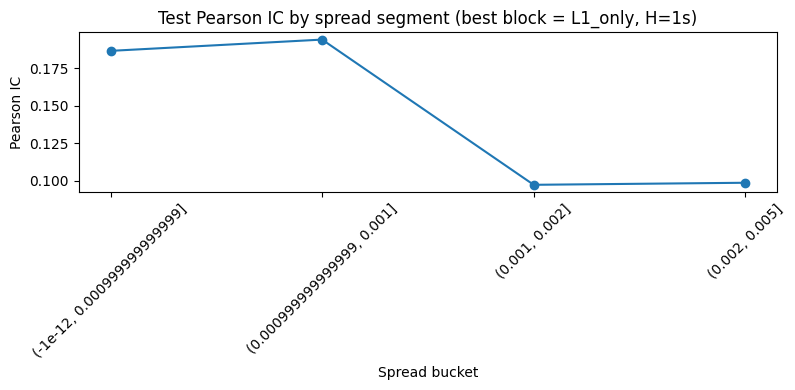

In [52]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(segment_metrics["segment"], segment_metrics["pearson_ic"], marker="o")
ax.set_title(f"Test Pearson IC by spread segment (best block = {best_block}, H={best_h}s)")
ax.set_xlabel("Spread bucket")
ax.set_ylabel("Pearson IC")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [53]:
ablation_metrics = pd.concat(
    [
        ablation_screen_metrics,
        final_test_results,
    ],
    ignore_index=True
)

tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

ablation_metrics.to_csv(tables_dir / "ablation_metrics.csv", index=False)
final_test_results.to_csv(tables_dir / "final_model_comparison.csv", index=False)
segment_metrics.to_csv(tables_dir / "segment_metrics.csv", index=False)

print("Saved to:", tables_dir.resolve())

Saved to: /home/zakhar/PycharmProjects/PythonProject5/outputs/tables


#### Purpose
Test whether the instability of the nonlinear model is mainly due to default hyperparameters or due to the underlying signal itself.

#### What it does
- Takes the best validation feature block,
- Runs a small Optuna search over LightGBM hyperparameters,
- Optimizes validation Pearson IC,
- Evaluates the tuned model once on test.

#### Why it matters
This shows whether tuning materially improves out-of-sample robustness.


In [54]:
import optuna
import lightgbm as lgb
best_h = 1
best_features = feature_blocks[best_block]
target_col = f"y_logret_{best_h}s"

# train on subsample, val full
X_train = df.loc[final_train_sub_idx, best_features].to_numpy(dtype=np.float32, copy=True)
y_train = df.loc[final_train_sub_idx, target_col].to_numpy()

X_val = df.loc[val_mask, best_features].to_numpy(dtype=np.float32, copy=True)
y_val = df.loc[val_mask, target_col].to_numpy()

def pearson_ic(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        return 0.0
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def objective(trial):
    params = {
        "objective": "regression",
        "n_estimators": 100,
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 7, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 50, 300),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "force_col_wise": True,
        "random_state": 42,
        "n_jobs": -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    pred_val = model.predict(X_val)
    return pearson_ic(y_val, pred_val)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

[I 2026-04-20 02:09:05,448] A new study created in memory with name: no-name-a758da96-32c3-48ab-9355-2ba89b78fcc6


  0%|          | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001


/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-04-20 02:09:05,925] Trial 0 finished with value: 0.13289162919991793 and parameters: {'learning_rate': 0.07277214560892478, 'num_leaves': 16, 'min_child_samples': 156, 'subsample': 0.9297284547076788, 'colsample_bytree': 0.6747784626587777, 'reg_alpha': 0.006097101899940896, 'reg_lambda': 0.008639293976038135}. Best is trial 0 with value: 0.13289162919991793.
[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001


...

[I 2026-04-20 02:09:13,499] Trial 17 finished with value: 0.10547969547188667 and parameters: {'learning_rate': 0.04140954313533473, 'num_leaves': 39, 'min_child_samples': 122, 'subsample': 0.8887473000108904, 'colsample_bytree': 0.5931166950895717, 'reg_alpha': 0.02006626443904759, 'reg_lambda': 1.7114439326316169}. Best is trial 2 with value: 0.1633884709440026.
[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-04-20 02:09:13,975] Trial 18 finished with value: 0.16153958500014462 and parameters: {'learning_rate': 0.02760160716878306, 'num_leaves': 48, 'min_child_samples': 205, 'subsample': 0.8153701003057803, 'colsample_bytree': 0.5045928580328498, 'reg_alpha': 0.20689063564612004, 'reg_lambda': 2.066724194637043}. Best is trial 2 with value: 0.1633884709440026.
[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[I 2026-04-20 02:09:14,722] Trial 19 finished with value: 0.09746510768760383 and parameters: {'learning_rate': 0.026485428230238667, 'num_leaves': 49, 'min_child_samples': 122, 'subsample': 0.7116387688453734, 'colsample_bytree': 0.5000082132918898, 'reg_alpha': 0.028547824749526544, 'reg_lambda': 3.1551107004512002}. Best is trial 2 with value: 0.1633884709440026.
Best value: 0.1633884709440026
Best params: {'learning_rate': 0.03244350416985566, 'num_leaves': 52, 'min_child_samples': 178, 'subsample': 0.8101655469728601, 'colsample_bytree': 0.5108946704284878, 'reg_alpha': 0.36919485553465253, 'reg_lambda': 4.672528311585735}


In [55]:
best_params = study.best_params.copy()
best_params.update({
    "objective": "regression",
    "n_estimators": 100,
    "force_col_wise": True,
    "random_state": 42,
    "n_jobs": -1,
})

X_test = df.loc[test_mask, best_features].to_numpy(dtype=np.float32, copy=True)
y_test = df.loc[test_mask, target_col].to_numpy()

tuned_model = lgb.LGBMRegressor(**best_params)
tuned_model.fit(X_train, y_train)

pred_val_tuned = tuned_model.predict(X_val)
pred_test_tuned = tuned_model.predict(X_test)

tuned_summary = pd.DataFrame([
    {
        "split": "val",
        "pearson_ic": pearson_ic(y_val, pred_val_tuned),
    },
    {
        "split": "test",
        "pearson_ic": pearson_ic(y_test, pred_test_tuned),
    },
])

tuned_summary

[LightGBM] [Info] Total Bins 1314
[LightGBM] [Info] Number of data points in the train set: 250000, number of used features: 8
[LightGBM] [Info] Start training from score 0.000001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/zakhar/PycharmProjects/PythonProject5/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,pearson_ic
0,val,0.163388
1,test,0.182347


In [57]:
# --- tuned model metrics ---
tuned_results = pd.DataFrame([
    {
        **regression_metrics(y_val, pred_val_tuned),
        "model": "lightgbm_tuned",
        "feature_block": best_block,
        "split": "val",
        "horizon_sec": best_h,
    },
    {
        **regression_metrics(y_test, pred_test_tuned),
        "model": "lightgbm_tuned",
        "feature_block": best_block,
        "split": "test",
        "horizon_sec": best_h,
    },
])

display(tuned_results)

# --- update full ablation table ---
ablation_metrics = pd.concat(
    [
        ablation_metrics,
        tuned_results,
    ],
    ignore_index=True
)

# --- update final test comparison ---
final_model_comparison = pd.concat(
    [
        final_test_results,
        tuned_results.query("split == 'test'"),
    ],
    ignore_index=True
)

display(final_model_comparison)

# --- save updated tables ---
tables_dir = Path("outputs/tables")
tables_dir.mkdir(parents=True, exist_ok=True)

ablation_metrics.to_csv(tables_dir / "ablation_metrics.csv", index=False)
final_model_comparison.to_csv(tables_dir / "final_model_comparison.csv", index=False)

print("Saved updated tables to:", tables_dir.resolve())

,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
0,196165,0.000058,0.000031,0.016857,0.163388,0.242816,lightgbm_tuned,L1_only,val,1
1,197350,0.000069,0.000038,0.009134,0.182347,0.262863,lightgbm_tuned,L1_only,test,1


,n_obs,rmse,mae,r2,pearson_ic,spearman_ic,model,feature_block,split,horizon_sec
0,197350,0.000069,0.000040,0.012123,0.155258,0.210693,imbalance_calibrated,baseline_reference,test,1
1,197350,0.000073,0.000045,-0.107806,0.109027,0.160643,ridge,plus_flow,test,1
2,197350,0.000070,0.000039,-0.001279,0.131251,0.203093,lightgbm,L1_only,test,1
3,197350,0.000069,0.000038,0.009134,0.182347,0.262863,lightgbm_tuned,L1_only,test,1


Saved updated tables to: /home/zakhar/PycharmProjects/PythonProject5/outputs/tables


## Optional hyperparameter tuning findings

- After introducing a purged split and adding Ridge as an intermediate benchmark, the default nonlinear comparison becomes more informative: the strongest default LightGBM feature block is now `L1_only`, not the broader `L1_plus_imb_micro` block.

- Ridge is useful as a diagnostic benchmark but does not generalize robustly out of sample. Its best validation specification (`plus_flow`) reaches a high validation Pearson IC, but test performance deteriorates materially, with weaker IC and negative R².

- Default LightGBM is more stable than Ridge on held-out test, but still does not beat the calibrated imbalance baseline in its untuned form.

- A focused Optuna search on the best LightGBM block improves held-out test ranking quality substantially. In the current setup, the tuned LightGBM reaches the strongest test Pearson IC among the tested supervised models and exceeds the imbalance baseline on this metric.

- The interpretation is therefore more nuanced than before: the imbalance model remains the strongest simple and most interpretable benchmark, Ridge does not transfer out of sample, and a carefully regularized nonlinear model shows the strongest held-out ranking signal in the current purged single-session experiment.

- At the same time, this result is still based on a single trading session and one held-out test slice. Therefore, the nonlinear uplift should be treated as promising rather than fully established until it is validated across additional days and market regimes.

## Short notebook conclusion
With a purged split in place, the strongest default nonlinear feature block is `L1_only`, suggesting that the most robust signal is concentrated in top-of-book information. Ridge serves as a useful intermediate supervised benchmark, but its validation uplift does not transfer out of sample. The calibrated imbalance model remains the strongest simple baseline, while an Optuna-tuned LightGBM achieves the highest held-out Pearson IC in the current single-session setup. The most honest takeaway is that short-horizon signal does exist, most of it is already captured by simple order-book structure, and additional nonlinear uplift looks promising but still requires cross-day robustness validation.